# 02 · Data preparation

A nowcasting panel is messy by construction:

* **mixed frequencies** — GDP is quarterly, most indicators are monthly;
* **non-stationarity** — indices in levels must be turned into growth rates or
  differences before a factor model can be estimated (Stock & Watson, 2002);
* **outliers** — strikes, droughts, tax changes and, above all, the 2020 pandemic;
* **missing values** — series that start late, interior gaps and the **ragged edge**:
  at any date, the most recent observations of each series are missing because of
  different publication delays (Giannone, Reichlin & Small, 2008).

This notebook walks through the tools that handle each problem: the
`MixedFrequencyData` container, the transformation codes, the outlier and missing-value
tools of `nowcastbox.preprocessing`, and `prepare_panel`, which chains them.

In [1]:
import sys
from pathlib import Path

HERE = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
sys.path.insert(0, str(HERE.parent))

import numpy as np
import pandas as pd
from utils import SEED, display, md, setup, show

import nowcastbox as nb
from nowcastbox import preprocessing as pp

setup()

## 1. The `MixedFrequencyData` contract

Every estimator consumes a `MixedFrequencyData`: a `DataFrame` on a contiguous
**monthly** `PeriodIndex` plus per-series metadata. A quarterly value lives in the
**last month** of its quarter (March, June, September, December); the other two
months are structural `NaN`. Building one from scratch takes a DataFrame and the
native frequencies; release delays (in days after the end of the reference period)
make pseudo real-time vintages possible.

In [2]:
rng = np.random.default_rng(SEED)
idx = pd.period_range("2024-01", periods=9, freq="M")
toy = pd.DataFrame(
    {
        "ip": 100 + rng.standard_normal(9).cumsum(),  # monthly industrial production
        "gdp": [np.nan, np.nan, 1.0, np.nan, np.nan, 1.2, np.nan, np.nan, np.nan],
    },
    index=idx,
)
toy_data = nb.MixedFrequencyData(
    toy,
    frequencies={"ip": "M", "gdp": "Q"},
    release_delays={"ip": 40, "gdp": 60},
)
display(toy_data.metadata_frame()[["frequency", "release_delay"]])
display(toy_data.to_native("gdp"))  # the quarterly series on its own quarterly index

,frequency,release_delay
series,,
ip,M,40
gdp,Q,60


period
2024Q1    1.0
2024Q2    1.2
2024Q3    NaN
Freq: Q-DEC, Name: gdp, dtype: float64

A value in a month that is not a quarter end, or an `inf`, is rejected with an
explicit `NowcastDataError` rather than silently accepted:

In [3]:
bad = toy.copy()
bad.loc[pd.Period("2024-02", "M"), "gdp"] = 0.7  # February is not a quarter end
try:
    nb.MixedFrequencyData(bad, frequencies={"ip": "M", "gdp": "Q"})
except nb.NowcastDataError as err:
    print(f"NowcastDataError: {err}")

NowcastDataError: Series 'gdp' is quarterly but has values outside the last monthly period of its periods, e.g. at ['2024-02'].


## 2. A real panel: the shipped Brazilian dataset

`load_brazil_nowcast()` returns a `Dataset`: values **in levels** as published, plus a
legend with source codes, frequencies, the stationarity transformation, the typical
publication delay, factor blocks and category (hard/soft/financial). We keep eight
representative series for the illustrations.

In [4]:
cols = [
    "pib",  # GDP volume index, SA (quarterly) - the target
    "ibc_br",  # BCB economic activity index (monthly GDP proxy)
    "pim_geral",  # industrial production
    "pmc_varejo",  # retail sales
    "ipca",  # consumer prices
    "selic",  # policy rate
    "energia_consumo_total",  # electricity consumption (not seasonally adjusted)
    "focus_pib",  # Focus survey: expected GDP growth
]
ds = nb.load_brazil_nowcast().select(cols).truncate("2010-01", None)
print(ds.summary())
display(ds.legend[["description", "frequency", "transform", "delay_days", "category"]])

Dataset 'brazil_nowcast': Brazilian nowcasting panel (BCB, IBGE, IPEA)
  Sample        : 2010-01 to 2026-09 (201 months)
  Series        : 8 (M: 7, Q: 1)
  Categories    : hard: 6, financial: 1, soft: 1
  Blocks        : global, real, nominal, financial, soft
  Target        : pib
  License       : Data: BCB series under the Open Data Commons Open Database License (ODbL 1.0) as published on dadosabertos.bcb.gov.br; IBGE and IPEADATA public data, free reuse with attribution of the source. Only open-license sources are included.
  Sources       : Banco Central do Brasil - SGS (dadosabertos.bcb.gov.br), ODbL; Banco Central do Brasil - Focus market expectations (Olinda API), ODbL; IBGE - SIDRA (sidra.ibge.gov.br), free use with attribution; IPEADATA (ipeadata.gov.br), free use citing IPEA and the original source (EPE/Eletrobras, ANP, SECEX/MDIC, Receita Federal, Ministry of Labour)


,description,frequency,transform,delay_days,category
series,,,,,
pib,GDP at market prices - chained quarterly volum...,Q,qoq,62,hard
ibc_br,"IBC-Br, Central Bank economic activity index, ...",M,dlog,46,hard
pim_geral,Industrial production (PIM-PF) - general indus...,M,dlog,35,hard
pmc_varejo,"Retail trade sales volume (PMC), seasonally ad...",M,dlog,42,hard
ipca,IPCA consumer price index,M,dlog,10,hard
selic,"Selic policy rate, monthly accumulated, annual...",M,diff,1,financial
energia_consumo_total,"Electricity consumption, total (EPE/Eletrobras...",M,dlog_yoy,30,hard
focus_pib,"Focus survey: median expected real GDP growth,...",M,diff,0,soft


## 3. Transformations

Each legend row carries a **named** transformation; the numeric codes 0–7 used by the
R package `nowcasting` (`Bpanel`) are also accepted. Every transformation is an
invertible object, so nowcasts of growth rates can be mapped back to levels.

In [5]:
codes = pd.DataFrame(
    {
        "code": list(pp.TRANSFORM_CODES),
        "transformation": [str(pp.transform_from_code(c)) for c in pp.TRANSFORM_CODES],
    }
).set_index("code")
named = pd.Series({k: str(pp.get_transform(k)) for k in ["dlog", "qoq", "yoy", "dlog_yoy"]})
display(codes, named.rename("named transformation").to_frame())

,transformation
code,
0,level
1,pct_change(1)
2,diff(1)
3,pct_change(year)|diff(1)
4,diff(year)|diff(1)
5,diff(year)
6,pct_change(year)
7,pct_change(quarter)


,named transformation
dlog,log|diff(1)
qoq,pct_change(quarter)
yoy,pct_change(year)
dlog_yoy,log|diff(year)


Seasonally adjusted activity indices enter as monthly log-differences (`dlog`), GDP as
quarter-on-quarter growth (`qoq`), the non-seasonally-adjusted electricity consumption
as a 12-month log-difference (`dlog_yoy`, which removes seasonality), rates in first
differences. `apply_transforms` applies them and records the fact in the metadata
(`transform_applied=True`), so applying them twice is a no-op.

In [6]:
stationary = nb.apply_transforms(ds.data, ds.transform)
display(stationary.data.tail(4))
print(stationary.metadata["ibc_br"].transform, stationary.metadata["ibc_br"].transform_applied)

,pib,ibc_br,pim_geral,pmc_varejo,ipca,selic,energia_consumo_total,focus_pib
period,,,,,,,,
2026-06,0.0048,-0.0089,-0.0165,0.0031,0.0016,-0.11,0.0194,0.0186
2026-07,NaN,-0.0022,0.0017,-0.0085,0.0007,-0.14,0.0360,-0.0252
2026-08,NaN,NaN,NaN,NaN,-0.0032,-0.21,NaN,-0.1192
2026-09,NaN,NaN,NaN,NaN,NaN,-0.16,NaN,-0.0939


dlog True


In [7]:
back = nb.invert_transforms(stationary, ds.data)  # needs the history in levels
err = (back.data["ibc_br"] - ds.data.data["ibc_br"]).abs().max()
print(f"max |levels - inverted(transformed)| for ibc_br: {err:.2e}")

max |levels - inverted(transformed)| for ibc_br: 0.00e+00


## 4. Outliers

`detect_outliers` flags observations farther than `threshold` inter-quartile ranges
from the median (the rule used by Giannone et al. and the R package, applied here
from the literature). On the Brazilian panel the flags concentrate in the pandemic
(March-September 2020), with an earlier episode in May-June 2018: the nationwide
truckers' strike that paralysed industry for ten days and the rebound that followed.

In [8]:
flags = pp.detect_outliers(stationary, threshold=4.0)
flagged = flags.stack()  # noqa: PD013
flagged = flagged[flagged]
display(flagged.reset_index().groupby("period")["level_1"].apply(list).rename("series"))

period
2018-05                                   [pim_geral]
2018-06                                   [pim_geral]
2020-03                           [ibc_br, pim_geral]
2020-04    [ibc_br, pim_geral, pmc_varejo, focus_pib]
2020-05            [pim_geral, pmc_varejo, focus_pib]
2020-06          [pib, ibc_br, pim_geral, pmc_varejo]
2020-07                        [pim_geral, focus_pib]
2020-08                                   [focus_pib]
2020-09                                         [pib]
2021-03                                      [ibc_br]
Freq: M, Name: series, dtype: object

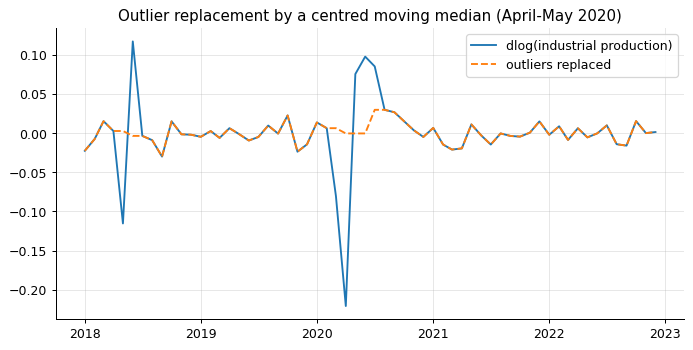

In [9]:
import matplotlib.pyplot as plt

clean = pp.replace_outliers(stationary, threshold=4.0, window=3, replacement="moving_median")
fig, ax = plt.subplots()
raw = stationary.data["pim_geral"].loc["2018-01":"2022-12"]
fixed = clean.data["pim_geral"].loc["2018-01":"2022-12"]
ax.plot(raw.index.to_timestamp(), raw.to_numpy(), label="dlog(industrial production)")
ax.plot(fixed.index.to_timestamp(), fixed.to_numpy(), ls="--", label="outliers replaced")
ax.set_title("Outlier replacement by a centred moving median (April-May 2020)")
ax.legend()
show(fig, "02_outliers")

**Should the pandemic be "cleaned"?** Replacing the April 2020 collapse by a moving
median protects the factor loadings from a handful of extreme points, but it also
throws away the largest common shock in the sample. For the *estimation* of a DFM this
is usually a good trade-off; for nowcasting *during* such an episode it is not.
Notebook 10 compares this pre-cleaning with the robust alternatives built into the EM
(Student-t errors, outlier detection inside the EM, pandemic dummies; innovation I3).

## 5. Missing values and the ragged edge

Three kinds of missing data matter: **leading** (a series starts late), **interior**
(gaps), and the **ragged edge** at the end of the sample. The ragged edge is
information, not a problem to be fixed: it is what makes nowcasting a real-time
exercise. The Kalman filter handles it exactly; preprocessing should only fill
interior gaps.

In [10]:
display(stationary.last_observed().rename("last observation").to_frame())

,last observation
pib,2026-06
ibc_br,2026-07
pim_geral,2026-07
pmc_varejo,2026-07
ipca,2026-08
selic,2026-09
energia_consumo_total,2026-07
focus_pib,2026-09


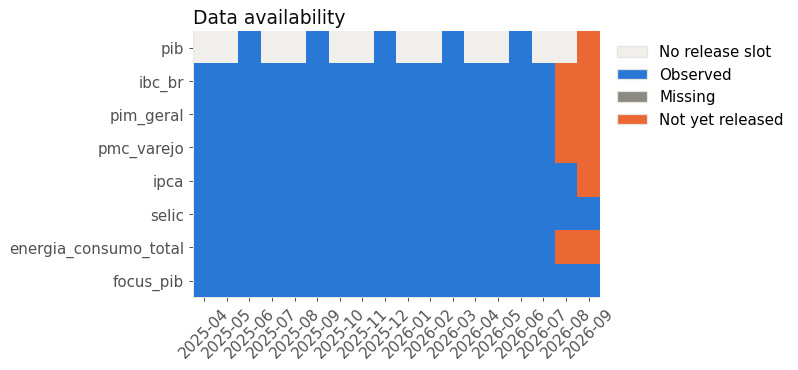

In [11]:
fig = nb.visualization.plot_data_availability(stationary, n_periods=18, backend="matplotlib")
show(fig, "02_ragged_edge")

On 1 October 2026 the policy rate and the Focus survey are known for September,
consumer prices for August, the activity indicators for July and GDP only for the
second quarter. The *same* panel seen on an earlier date is obtained with `as_of`,
which keeps an observation only if its release date (end of the reference period +
delay) is on or before the vintage date:

In [12]:
earlier = stationary.as_of("2026-06-15")
display(
    pd.DataFrame(
        {"2026-10-01 (today)": stationary.last_observed(), "2026-06-15": earlier.last_observed()}
    )
)

,2026-10-01 (today),2026-06-15
pib,2026-06,2026-03
ibc_br,2026-07,2026-04
pim_geral,2026-07,2026-04
pmc_varejo,2026-07,2026-04
ipca,2026-08,2026-05
selic,2026-09,2026-05
energia_consumo_total,2026-07,2026-04
focus_pib,2026-09,2026-05


## 6. `prepare_panel`: everything at once

`prepare_panel` applies the transformations, replaces outliers, fills **interior**
gaps by splines (never the ragged edge, unless asked), drops series with more than a
third of missing values and returns a report. It mirrors the role of `Bpanel` in the R
package `nowcasting` (de Valk et al., 2019), with named transformations and an
explicit audit trail.

In [13]:
full = nb.load_brazil_nowcast()
panel, report = nb.prepare_panel(full.data, full.transform, return_report=True)
md(
    f"`prepare_panel` kept **{panel.n_series}** of {full.n_series} series and dropped "
    f"{len(report.dropped)} with more than 1/3 missing values: "
    + ", ".join(f"`{c}`" for c in report.dropped)
)
summary = report.to_frame()
display(summary.sort_values("n_outliers", ascending=False).head(8))

`prepare_panel` kept **86** of 99 series and dropped 13 with more than 1/3 missing values: `pms_volume`, `desocupacao`, `desocupacao_sa`, `ocupacao_sa`, `massa_salarial_sa`, `caged_saldo`, `ipp_industria`, `credito_concessoes_sa`, `credito_concessoes_pf_sa`, `credito_concessoes_pj_sa`, `credito_taxa_juros`, `credito_spread`, `credito_inadimplencia`

,transform,missing_proportion,dropped,n_outliers,n_filled
series,,,,,
ipea_consumo_aparente_bk,log|diff(1),0.0140,False,17,0
reservas_internacionais,log|diff(1),0.0070,False,13,0
resultado_primario_12m,diff(1),0.0070,False,12,0
pim_veiculos,log|diff(1),0.0105,False,10,0
pim_bens_consumo_duraveis,log|diff(1),0.0105,False,10,0
pim_geral,log|diff(1),0.0105,False,9,0
pim_transformacao,log|diff(1),0.0105,False,9,0
pim_bens_capital,log|diff(1),0.0105,False,8,0


The dropped series (unemployment from the continuous PNAD, CAGED, credit concessions,
...) start in 2012 or later. They are informative about the recent past, so a modeller
may prefer to keep them with `max_na_prop=1.0` — the EM estimator handles arbitrary
missing patterns (Bańbura & Modugno, 2014), while the two-step estimator needs a
balanced block for its principal components.

## 7. Temporal aggregation (Mariano & Murasawa, 2003)

Quarterly GDP growth is not observed monthly, but it can be written as a weighted sum
of an unobserved monthly growth rate. With $y_t$ the monthly growth of the latent
monthly GDP (in logs), the quarterly growth is approximately

$$y^Q_t \approx \tfrac{1}{3}\left(y_t + 2y_{t-1} + 3y_{t-2} + 2y_{t-3} + y_{t-4}\right).$$

These triangular weights enter the measurement equation of the EM model as linear
restrictions on the loadings of quarterly series.

In [14]:
print("Mariano-Murasawa weights:", pp.mariano_murasawa_weights(3, normalize=True))
monthly_to_q = nb.month_to_quarter(ds.data.data["ibc_br"], how="mean")
display(monthly_to_q.tail(4).rename("ibc_br, quarterly average").to_frame())

Mariano-Murasawa weights: [0.33333333 0.66666667 1.         0.66666667 0.33333333]


,"ibc_br, quarterly average"
2025Q4,109.1520
2026Q1,110.4582
2026Q2,110.7321
2026Q3,NaN


### References

* Bańbura, M. & Modugno, M. (2014). *Journal of Applied Econometrics*, 29(1), 133–160.
* de Valk, S., de Mattos, D. & Ferreira, P. (2019). Nowcasting: an R package for
  predicting economic variables using dynamic factor models. *The R Journal*, 11(1).
* Giannone, D., Reichlin, L. & Small, D. (2008). *Journal of Monetary Economics*,
  55(4), 665–676.
* Mariano, R. S. & Murasawa, Y. (2003). A new coincident index of business cycles
  based on monthly and quarterly series. *Journal of Applied Econometrics*, 18(4),
  427–443.
* Stock, J. H. & Watson, M. W. (2002). Forecasting using principal components from a
  large number of predictors. *JASA*, 97(460), 1167–1179.